In [ ]:
# !pip install torch_geometric

In [ ]:
# import all libraries needed downstream
import os
import numpy as np
import torch
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from copy import deepcopy
from sklearn.metrics import mean_squared_error
import math
import networkx as nx
import seaborn as sns
import time
from torch.nn import Linear
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import degree
from torch_geometric.nn import ChebConv, GraphConv, GCNConv, TAGConv, GATConv
from torch_geometric.data import Data
from torch.utils.data import TensorDataset
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

/tmp/ipykernel_106071/1709458397.py:42: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df.pivot_table(index='System', columns='Model', values=['Base', 'Zero-shot'])
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


<Figure size 1400x800 with 0 Axes>

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


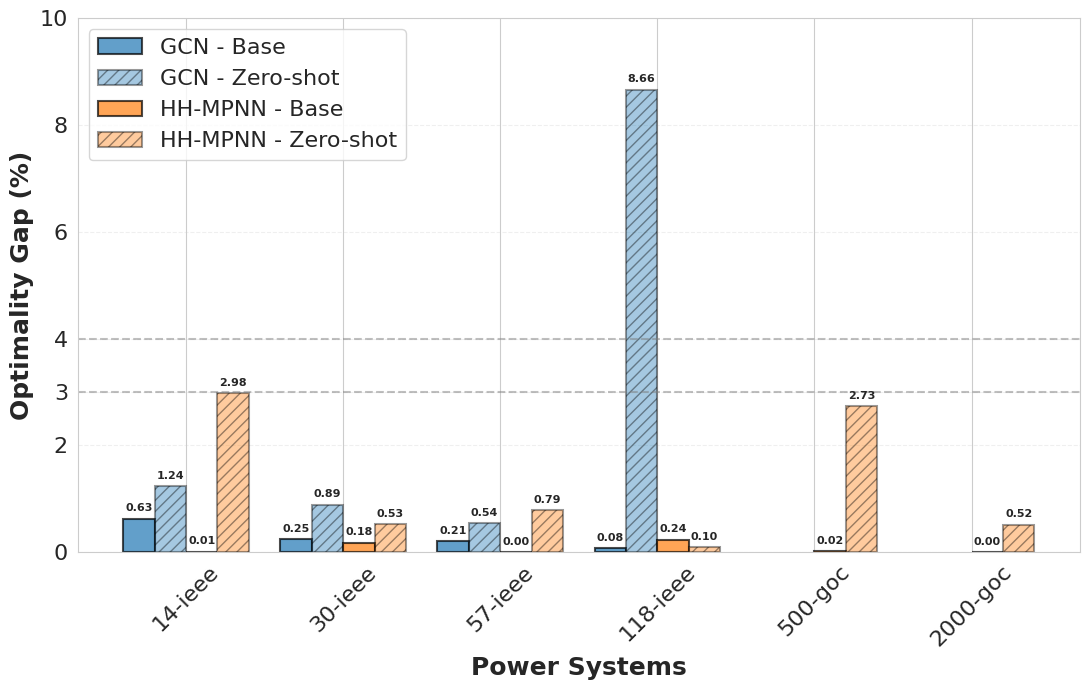

In [ ]:
# Create the dataframe from the table data
data = {
    'System': ['14-ieee', '14-ieee', '30-ieee', '30-ieee', '57-ieee', '57-ieee', 
               '118-ieee', '118-ieee', '500-goc', '2000-goc'],
    'Model': ['GCN', 'HH-MPNN', 'GCN', 'HH-MPNN', 'GCN', 'HH-MPNN', 'GCN', 'HH-MPNN', 'HH-MPNN', 'HH-MPNN'],
    'Base': [0.63, 0.01, 0.25, 0.18, 0.21, 0.00, 0.08, 0.24, 0.02, 0.00],
    'Zero-shot': [1.24, 2.98, 0.89, 0.53, 0.54, 0.79, 8.66, 0.10, 2.73, 0.52]
}

df = pd.DataFrame(data)

# Create a custom ordering of systems from smallest to largest
system_order = ['14-ieee', '30-ieee', '57-ieee', '118-ieee', '500-goc', '2000-goc']
df['System'] = pd.Categorical(df['System'], categories=system_order, ordered=True)

# Sort the dataframe by the ordered System column
df = df.sort_values('System')

# Reshape the dataframe to long format for easier plotting
df_long = pd.melt(df, id_vars=['System', 'Model'], 
                 value_vars=['Base', 'Zero-shot'],
                 var_name='Dataset', value_name='Optimality Gap (%)')

# Set the style
sns.set_style("whitegrid")

# Define a professional color palette
colors = sns.color_palette("tab10")

# Define model colors for consistency
model_colors = {'GCN': colors[0], 'HH-MPNN': colors[1]}

# Create the bar chart figure
plt.figure(figsize=(14, 8))

# Pivot the data for grouped bar chart
pivot_df = df.pivot_table(index='System', columns='Model', values=['Base', 'Zero-shot'])

# Ensure the systems are in the correct order for the bar chart
pivot_df = pivot_df.reindex(system_order)

# Define width of the bars
bar_width = 0.2
x = np.arange(len(pivot_df.index))

# Create the figure

bar_groups = []

fig, ax = plt.subplots(figsize=(11, 7))


if ('Base', 'GCN') in pivot_df.columns:
    bars = ax.bar(x - 1.5*bar_width, pivot_df[('Base', 'GCN')], bar_width,
                  label='GCN - Base', color=colors[0], alpha=0.7,
                  edgecolor='black', linewidth=1.5)
    bar_groups.append(bars)

if ('Zero-shot', 'GCN') in pivot_df.columns:
    bars = ax.bar(x - 0.5*bar_width, pivot_df[('Zero-shot', 'GCN')], bar_width,
                  label='GCN - Zero-shot', color=colors[0], alpha=0.4,
                  edgecolor='black', linewidth=1.5, hatch='///')
    bar_groups.append(bars)

if ('Base', 'HH-MPNN') in pivot_df.columns:
    bars = ax.bar(x + 0.5*bar_width, pivot_df[('Base', 'HH-MPNN')], bar_width,
                  label='HH-MPNN - Base', color=colors[1], alpha=0.7,
                  edgecolor='black', linewidth=1.5)
    bar_groups.append(bars)

if ('Zero-shot', 'HH-MPNN') in pivot_df.columns:
    bars = ax.bar(x + 1.5*bar_width, pivot_df[('Zero-shot', 'HH-MPNN')], bar_width,
                  label='HH-MPNN - Zero-shot', color=colors[1], alpha=0.4,
                  edgecolor='black', linewidth=1.5, hatch='///')
    bar_groups.append(bars)

# Add labels directly above each bar
for bars in bar_groups:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1,
                f'{height:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')


# Customize the plot
ax.set_xlabel('Power Systems', fontsize=18, fontweight='bold')
ax.set_ylabel('Optimality Gap (%)', fontsize=18, fontweight='bold')
# ax.set_title('Comparison of Train and Transfer Optimality Gaps by Model and System', 
#               fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index, rotation=45,fontsize=16)
ax.set_yticks([0, 2, 3, 4, 6, 8, 10])
ax.set_yticklabels([ytick for ytick in [0, 2, 3, 4, 6, 8, 10]], fontsize=16)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
ax.legend(loc='upper left', fontsize=16, frameon=True)

# Add horizontal lines for reference
# ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=3.0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=4.0, color='gray', linestyle='--', alpha=0.5)


# Highlight the best performance
min_idx = df['Base'].idxmin()
best_system = df.loc[min_idx, 'System']
best_model = df.loc[min_idx, 'Model']
best_val = df.loc[min_idx, 'Base']


plt.tight_layout()
plt.savefig('optimality_gap_comparison.pdf', dpi=1000, bbox_inches='tight')
plt.show()

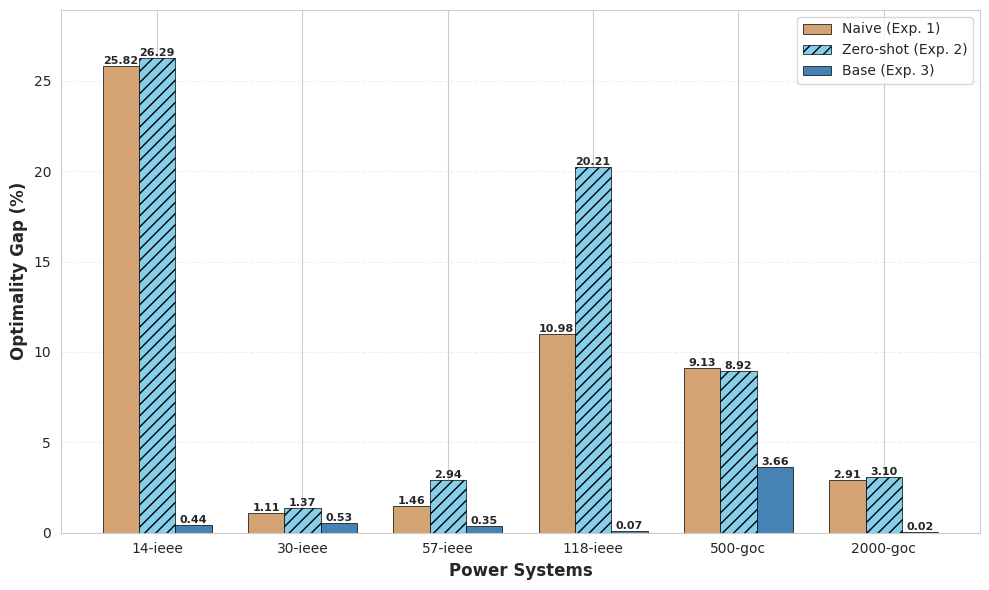

In [ ]:

# Data
systems = ['14-ieee', '30-ieee', '57-ieee', '118-ieee', '500-goc', '2000-goc']
Naive = [25.82, 1.11, 1.46, 10.98, 9.13, 2.91]
Zeroshot = [26.29, 1.37, 2.94, 20.21, 8.92, 3.10]
Base = [0.44, 0.53, 0.35, 0.07, 3.66, 0.02]

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 6))

# X-axis positions
x = np.arange(len(systems))
width = 0.25  # Width of bars

# Create bars
bars1 = ax.bar(x - width, Naive, width, label='Naive (Exp. 1)', 
               color='#D4A373', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, Zeroshot, width, label='Zero-shot (Exp. 2)', 
               color='#87CEEB', edgecolor='black', linewidth=0.5, hatch='///')
bars3 = ax.bar(x + width, Base, width, label='Base (Exp. 3)', 
               color='#4682B4', edgecolor='black', linewidth=0.5)

# Customize plot
ax.set_xlabel('Power Systems', fontsize=12, fontweight='bold')
ax.set_ylabel('Optimality Gap (%)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=0)
ax.legend(loc='upper right', frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limit to show all data clearly
ax.set_ylim(0, max(max(Naive), max(Zeroshot), max(Base)) * 1.1)

# Add value labels on top of bars (optional, only for values > 1%)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        # if height > 1.0:  # Only label significant values
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}',
               ha='center', va='bottom', fontsize=8,fontweight='bold')

plt.tight_layout()
plt.savefig('figure6_high_impact_contingencies.pdf', dpi=1000, bbox_inches='tight')
plt.savefig('figure6_high_impact_contingencies.png', dpi=1000, bbox_inches='tight')
plt.show()